# Nigeria Road Quality Baseline (NirTIMS)

This notebook loads the NirTIMS shapefiles and runs baseline analyses:
- Condition distribution (`SURFACECON`)
- Condition vs pavement type (`PAVETYPE`)
- Problem area burden (`PATYPE`)
- Defect density per road length


In [20]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style='whitegrid')

DATA_DIR = Path('/Users/miranda/Documents/GitHub/Sentinel-FYP/data/NirTIMS Shapefiles Nov 14 2025')
DATA_DIR


PosixPath('/Users/miranda/Documents/GitHub/Sentinel-FYP/data/NirTIMS Shapefiles Nov 14 2025')

In [21]:
# List available shapefiles
sorted([p.name for p in DATA_DIR.glob('*.shp')])


['Bridges.shp',
 'BusStops.shp',
 'Causeways.shp',
 'CrossingInfra.shp',
 'Culverts.shp',
 'EducationFacilities.shp',
 'HealthFacilities.shp',
 'HolyPlaces.shp',
 'KmStones.shp',
 'Markets.shp',
 'Poles.shp',
 'ProblemAreas.shp',
 'RoadCondition.shp',
 'RoadNetwork.shp',
 'RoadPavement.shp',
 'RoadSideDrains.shp',
 'RoadSideStructures.shp',
 'Settlements.shp',
 'SpeedBreakers.shp',
 'TrafficSigns.shp']

In [22]:
# Load core layers
road_cond = gpd.read_file(DATA_DIR / 'RoadCondition.shp')
road_net = gpd.read_file(DATA_DIR / 'RoadNetwork.shp')
road_pave = gpd.read_file(DATA_DIR / 'RoadPavement.shp')
problem = gpd.read_file(DATA_DIR / 'ProblemAreas.shp')

print('RoadCondition:', road_cond.shape)
print('RoadNetwork  :', road_net.shape)
print('RoadPavement :', road_pave.shape)
print('ProblemAreas :', problem.shape)


RoadCondition: (15953, 5)
RoadNetwork  : (6196, 7)
RoadPavement : (14793, 7)
ProblemAreas : (26028, 11)


In [23]:
# Keep essential columns
rc = road_cond[['ROADCODE', 'ROADNAME', 'SURFACECON', 'geometry']].copy()
rn = road_net[['ROADCODE', 'ROADCLASS', 'TOTALLEN', 'SHPLEN']].copy()
rp = road_pave[['ROADCODE', 'PAVETYPE', 'PAVEWIDTH', 'FORWIDTH']].copy()
pa = problem[['ROADCODE', 'PATYPE', 'PAINTERVEN', 'PALENGTH']].copy()

def norm_code(s):
    return (s.astype(str)
            .str.strip()
            .str.replace(r'\s+', '', regex=True)
            .str.upper())

for d in [rc, rn, rp, pa]:
    d['ROADCODE_N'] = norm_code(d['ROADCODE'])

rc.head()


,ROADCODE,ROADNAME,SURFACECON,geometry,ROADCODE_N
0,2308-00182,Epete - Otubo - Otubo Anayi - Uwowo - Ogbogbo ...,Poor,"LINESTRING Z (6.81184 7.15368 NaN, 6.81184 7.1...",2308-00182
1,2308-00182,Epete - Otubo - Otubo Anayi - Uwowo - Ogbogbo ...,Poor,"LINESTRING Z (6.81184 7.15368 NaN, 6.81184 7.1...",2308-00182
2,2308-00183,Ayikpele - Okochobe - Etutobo - Ufugu,Poor,"LINESTRING Z (6.83822 7.1846 NaN, 6.83822 7.18...",2308-00183
3,2308-00183,Ayikpele - Okochobe - Etutobo - Ufugu,Poor,"LINESTRING Z (6.85558 7.22966 NaN, 6.83822 7.1...",2308-00183
4,2308-00184,Imere junction - Akpa - Ibochi - Ojofa - Ugbat...,Poor,"LINESTRING Z (6.85211 7.21882 NaN, 6.85211 7.2...",2308-00184


In [24]:
# Join RoadCondition to network and pavement info
base = rc.merge(rn.drop_duplicates('ROADCODE_N'), on='ROADCODE_N', how='left', suffixes=('', '_net'))
base = base.merge(rp.drop_duplicates('ROADCODE_N'), on='ROADCODE_N', how='left', suffixes=('', '_pave'))

base['SURFACECON'] = base['SURFACECON'].astype(str).str.strip()
base['PAVETYPE'] = base['PAVETYPE'].astype(str).str.strip()
base['ROADCLASS'] = base['ROADCLASS'].astype(str).str.strip()

base[['ROADCODE', 'SURFACECON', 'ROADCLASS', 'PAVETYPE']].head()


,ROADCODE,SURFACECON,ROADCLASS,PAVETYPE
0,2308-00182,Poor,Trunk C Township,nan
1,2308-00182,Poor,Trunk C Township,nan
2,2308-00183,Poor,Trunk C Township,EARTHEN
3,2308-00183,Poor,Trunk C Township,EARTHEN
4,2308-00184,Poor,Trunk C Township,EARTHEN


In [25]:
# 1) Condition distribution
cond_counts = base['SURFACECON'].value_counts(dropna=False).rename_axis('SURFACECON').reset_index(name='count')
cond_counts['pct'] = (cond_counts['count'] / cond_counts['count'].sum() * 100).round(2)
cond_counts


,SURFACECON,count,pct
0,Poor,6452,40.44
1,Fair,4379,27.45
2,Very Poor,2955,18.52
3,Good,1695,10.62
4,Excellent,468,2.93
5,None,4,0.03


In [26]:
# 2) Condition vs pavement type
ct = pd.crosstab(base['PAVETYPE'], base['SURFACECON'])
ct_pct = pd.crosstab(base['PAVETYPE'], base['SURFACECON'], normalize='index') * 100

display(ct)
display(ct_pct.round(2))


SURFACECON,Excellent,Fair,Good,None,Poor,Very Poor
PAVETYPE,,,,,,
ASPHALT CONCRETE,226,649,907,1,903,329
CONCRETE,3,25,14,0,49,25
DBST,38,144,81,1,179,138
EARTHEN,161,3067,574,2,4804,2155
GRAVEL,28,292,81,0,341,221
None,0,2,0,0,1,0
OTTA SEAL,0,2,1,0,4,1
SBST,6,147,29,0,96,61
STONE PAVEMENT,5,28,3,0,27,13


SURFACECON,Excellent,Fair,Good,None,Poor,Very Poor
PAVETYPE,,,,,,
ASPHALT CONCRETE,7.50,21.53,30.08,0.03,29.95,10.91
CONCRETE,2.59,21.55,12.07,0.00,42.24,21.55
DBST,6.54,24.78,13.94,0.17,30.81,23.75
EARTHEN,1.50,28.50,5.33,0.02,44.63,20.02
GRAVEL,2.91,30.32,8.41,0.00,35.41,22.95
None,0.00,66.67,0.00,0.00,33.33,0.00
OTTA SEAL,0.00,25.00,12.50,0.00,50.00,12.50
SBST,1.77,43.36,8.55,0.00,28.32,17.99
STONE PAVEMENT,6.58,36.84,3.95,0.00,35.53,17.11


In [27]:
# 3) Problem area counts by type
pa_counts = pa['PATYPE'].value_counts(dropna=False).rename_axis('PATYPE').reset_index(name='count')
pa_counts['pct'] = (pa_counts['count'] / pa_counts['count'].sum() * 100).round(2)
pa_counts


,PATYPE,count,pct
0,Erosion,13385,51.43
1,Waterlogging,11218,43.10
2,Landslide,1425,5.47


In [28]:
# 4) Defect density by road (problem points per km)
# Use SHPLEN if numeric and valid; fallback to geometry length in degrees converted approx if unavailable
road_len = rc[['ROADCODE_N', 'geometry']].copy()
road_len['geom_len_deg'] = road_len.geometry.length

net_len = rn[['ROADCODE_N', 'SHPLEN', 'TOTALLEN']].copy()
for c in ['SHPLEN', 'TOTALLEN']:
    net_len[c] = pd.to_numeric(net_len[c], errors='coerce')

road_len = road_len.merge(net_len, on='ROADCODE_N', how='left')
# choose a length field
road_len['len_km'] = road_len['SHPLEN']
road_len.loc[(road_len['len_km'].isna()) | (road_len['len_km'] <= 0), 'len_km'] = road_len['TOTALLEN']

# problem count per road
prob_n = pa.groupby('ROADCODE_N').size().rename('problem_n').reset_index()
dens = road_len[['ROADCODE_N', 'len_km']].drop_duplicates('ROADCODE_N').merge(prob_n, on='ROADCODE_N', how='left')
dens['problem_n'] = dens['problem_n'].fillna(0)
dens['len_km'] = pd.to_numeric(dens['len_km'], errors='coerce')
dens = dens[dens['len_km'] > 0].copy()
dens['problems_per_10km'] = dens['problem_n'] / dens['len_km'] * 10

dens[['problem_n', 'len_km', 'problems_per_10km']].describe()


/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_91906/1502589486.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  road_len['geom_len_deg'] = road_len.geometry.length


,problem_n,len_km,problems_per_10km
count,4573.000000,4573.000000,4573.000000
mean,5.538159,5.939812,25.284480
std,10.262122,7.073822,304.921272
min,0.000000,0.002000,0.000000
25%,0.000000,1.628000,0.000000
50%,2.000000,3.758000,5.147012
75%,6.000000,7.697000,15.717092
max,148.000000,110.444000,16000.000000


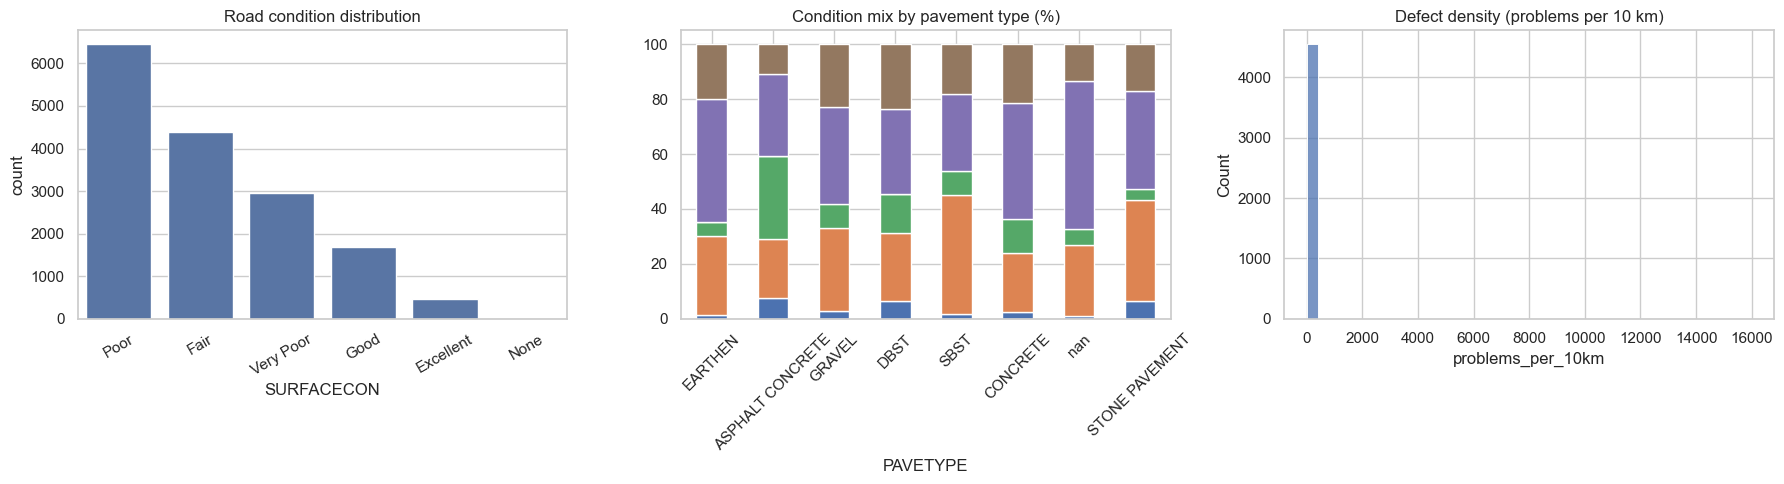

In [29]:
# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=cond_counts, x='SURFACECON', y='count', ax=axes[0])
axes[0].set_title('Road condition distribution')
axes[0].tick_params(axis='x', rotation=30)

top_pave = ct.sum(axis=1).sort_values(ascending=False).head(8).index
ct_top = ct_pct.loc[top_pave] if len(top_pave) else ct_pct
ct_top.plot(kind='bar', stacked=True, ax=axes[1], legend=False)
axes[1].set_title('Condition mix by pavement type (%)')
axes[1].tick_params(axis='x', rotation=45)

sns.histplot(dens['problems_per_10km'], bins=40, ax=axes[2])
axes[2].set_title('Defect density (problems per 10 km)')

plt.tight_layout()
plt.show()


## Next steps
- Join `RoadSideDrains`, `Culverts`, and `Bridges` by `ROADCODE_N` to explain waterlogging and erosion risk.
- Build a binary target (`Poor/Very Poor` vs `Good/Fair/Excellent`) for predictive baseline modeling.
- Add state/region boundary layer to compute regional summaries and hotspots.


In [30]:
# Step 1 — Join drains, culverts, bridges to road-level table (ROADCODE_N)

# Load extra infrastructure layers
dr = gpd.read_file(DATA_DIR / "RoadSideDrains.shp")
cu = gpd.read_file(DATA_DIR / "Culverts.shp")
br = gpd.read_file(DATA_DIR / "Bridges.shp")

for d in [dr, cu, br]:
    d["ROADCODE_N"] = norm_code(d["ROADCODE"])

# Aggregate per road
dr_agg = (
    dr.groupby("ROADCODE_N")
    .agg(
        drains_n=("ROADCODE_N", "size"),
        drain_types_n=("DRAINTYPE", "nunique"),
        drain_interv_n=("DRAININTER", lambda s: s.astype("string").str.strip().replace({"<NA>": pd.NA}).dropna().shape[0])
    )
    .reset_index()
)

cu_agg = (
    cu.groupby("ROADCODE_N")
    .agg(
        culverts_n=("ROADCODE_N", "size"),
        culvert_types_n=("CULVERTTYP", "nunique")
    )
    .reset_index()
)

br_agg = (
    br.groupby("ROADCODE_N")
    .agg(
        bridges_n=("ROADCODE_N", "size")
    )
    .reset_index()
)

# Merge into base
base_inf = (
    base.merge(dr_agg, on="ROADCODE_N", how="left")
        .merge(cu_agg, on="ROADCODE_N", how="left")
        .merge(br_agg, on="ROADCODE_N", how="left")
)

for c in ["drains_n", "drain_types_n", "drain_interv_n", "culverts_n", "culvert_types_n", "bridges_n"]:
    base_inf[c] = base_inf[c].fillna(0)

base_inf[["ROADCODE_N","SURFACECON","drains_n","culverts_n","bridges_n"]].head()


,ROADCODE_N,SURFACECON,drains_n,culverts_n,bridges_n
0,2308-00182,Poor,0.0,2.0,0.0
1,2308-00182,Poor,0.0,2.0,0.0
2,2308-00183,Poor,0.0,0.0,0.0
3,2308-00183,Poor,0.0,0.0,0.0
4,2308-00184,Poor,1.0,0.0,0.0


In [31]:
# Link problem-area waterlogging/erosion to the same roads
pa2 = pa.copy()
pa2["PATYPE_C"] = pa2["PATYPE"].astype("string").str.strip().str.title()

pa_agg = (
    pa2.groupby(["ROADCODE_N", "PATYPE_C"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Ensure expected columns exist
for c in ["Waterlogging", "Erosion", "Landslide"]:
    if c not in pa_agg.columns:
        pa_agg[c] = 0

base_inf = base_inf.merge(pa_agg[["ROADCODE_N","Waterlogging","Erosion","Landslide"]], on="ROADCODE_N", how="left")
for c in ["Waterlogging","Erosion","Landslide"]:
    base_inf[c] = base_inf[c].fillna(0)

base_inf[["SURFACECON","Waterlogging","Erosion","Landslide","drains_n","culverts_n","bridges_n"]].head()


,SURFACECON,Waterlogging,Erosion,Landslide,drains_n,culverts_n,bridges_n
0,Poor,0.0,0.0,0.0,0.0,2.0,0.0
1,Poor,0.0,0.0,0.0,0.0,2.0,0.0
2,Poor,0.0,0.0,0.0,0.0,0.0,0.0
3,Poor,0.0,0.0,0.0,0.0,0.0,0.0
4,Poor,0.0,0.0,0.0,1.0,0.0,0.0


In [32]:
# Summary by 5-class road condition (keep all five classes)
summary = (
    base_inf.groupby("SURFACECON")
    .agg(
        roads_n=("ROADCODE_N", "nunique"),
        mean_waterlogging=("Waterlogging", "mean"),
        mean_erosion=("Erosion", "mean"),
        mean_landslide=("Landslide", "mean"),
        mean_drains=("drains_n", "mean"),
        mean_culverts=("culverts_n", "mean"),
        mean_bridges=("bridges_n", "mean")
    )
    .sort_values("roads_n", ascending=False)
)

summary


,roads_n,mean_waterlogging,mean_erosion,mean_landslide,mean_drains,mean_culverts,mean_bridges
SURFACECON,,,,,,,
Poor,2554,4.141197,4.842529,0.535648,5.266894,3.214817,0.373993
Fair,2196,4.743777,5.433661,0.810002,3.513359,4.002969,0.337063
Very Poor,1173,4.786125,5.348223,0.649069,3.993570,3.900846,0.572589
Good,959,3.452507,4.394100,0.941003,5.113274,5.423599,0.303245
Excellent,290,3.504274,5.946581,1.636752,3.262821,5.948718,0.491453
None,4,4.250000,5.000000,0.500000,1.000000,5.500000,0.750000


In [34]:
# 1) Check key uniqueness in each layer
print("base unique ROADCODE_N:", base["ROADCODE_N"].nunique(), "rows:", len(base))
print("dr_agg unique ROADCODE_N:", dr_agg["ROADCODE_N"].nunique(), "rows:", len(dr_agg))
print("cu_agg unique ROADCODE_N:", cu_agg["ROADCODE_N"].nunique(), "rows:", len(cu_agg))
print("br_agg unique ROADCODE_N:", br_agg["ROADCODE_N"].nunique(), "rows:", len(br_agg))
print("pa_agg unique ROADCODE_N:", pa_agg["ROADCODE_N"].nunique(), "rows:", len(pa_agg))


base unique ROADCODE_N: 4573 rows: 15953
dr_agg unique ROADCODE_N: 4289 rows: 4289
cu_agg unique ROADCODE_N: 2681 rows: 2681
br_agg unique ROADCODE_N: 600 rows: 600
pa_agg unique ROADCODE_N: 3107 rows: 3107


In [35]:
# 2) Enforce 1 row per ROADCODE_N for condition base (avoid repeated segments by code)
base_u = (
    base.sort_values("ROADCODE_N")
        .drop_duplicates("ROADCODE_N")
        .copy()
)

# Merge again from unique base
base_inf_u = (
    base_u.merge(dr_agg, on="ROADCODE_N", how="left")
          .merge(cu_agg, on="ROADCODE_N", how="left")
          .merge(br_agg, on="ROADCODE_N", how="left")
          .merge(pa_agg[["ROADCODE_N","Waterlogging","Erosion","Landslide"]], on="ROADCODE_N", how="left")
)

for c in ["drains_n","drain_types_n","drain_interv_n","culverts_n","culvert_types_n","bridges_n","Waterlogging","Erosion","Landslide"]:
    if c in base_inf_u.columns:
        base_inf_u[c] = base_inf_u[c].fillna(0)

# keep only valid condition classes
valid_cond = ["Excellent","Good","Fair","Poor","Very Poor"]
base_inf_u = base_inf_u[base_inf_u["SURFACECON"].isin(valid_cond)].copy()

print("Rows after dedupe/filter:", len(base_inf_u))


Rows after dedupe/filter: 4573


In [43]:
# 3) Recompute summary
summary_u = (
    base_inf_u.groupby("SURFACECON")
    .agg(
        roads_n=("ROADCODE_N","nunique"),
        mean_waterlogging=("Waterlogging","mean"),
        mean_erosion=("Erosion","mean"),
        mean_landslide=("Landslide","mean"),
        mean_drains=("drains_n","mean"),
        mean_culverts=("culverts_n","mean"),
        mean_bridges=("bridges_n","mean"),
    )
)
summary_u


,roads_n,mean_waterlogging,mean_erosion,mean_landslide,mean_drains,mean_culverts,mean_bridges
SURFACECON,,,,,,,
Excellent,132,1.734848,1.363636,0.340909,3.401515,4.204545,0.280303
Fair,1496,2.628342,3.215909,0.360963,2.405080,3.127674,0.238636
Good,592,2.179054,2.354730,0.376689,3.197635,3.464527,0.217905
Poor,1723,2.237377,2.788741,0.220546,2.444573,1.959954,0.173535
Very Poor,630,2.609524,2.861905,0.309524,2.282540,1.984127,0.252381


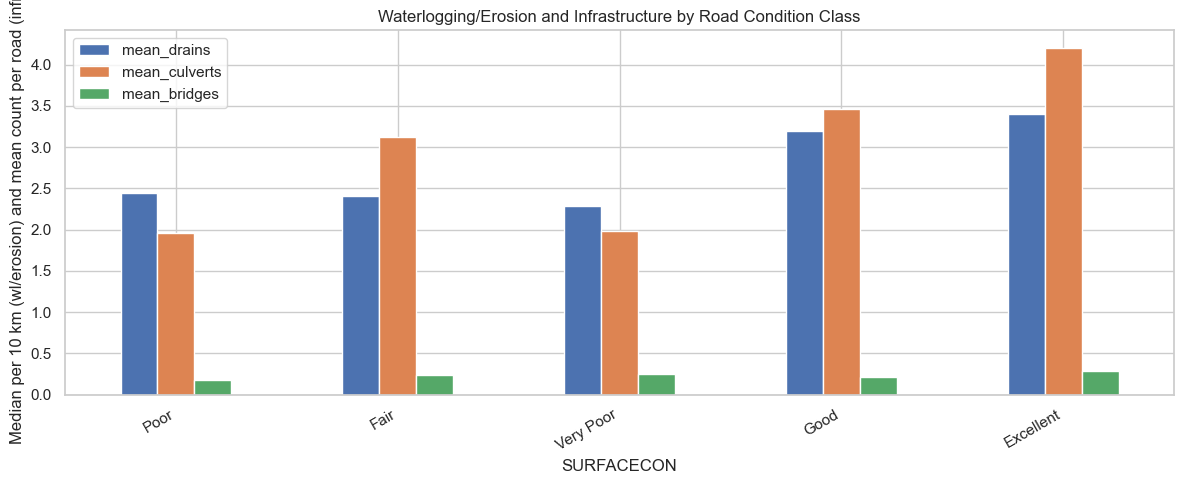

In [46]:
# Same style as previous graph, but safe for current norm_summary columns
order = ["Poor", "Fair", "Very Poor", "Good", "Excellent"]
plot_df = summary_u.reindex(order).copy()

candidate_cols = ["wl_med", "er_med", "mean_drains", "mean_culverts", "mean_bridges"]
plot_cols = [c for c in candidate_cols if c in plot_df.columns]

if not plot_cols:
    raise ValueError(f"No expected columns found. Available columns: {plot_df.columns.tolist()}")

plot_df[plot_cols].plot(kind="bar", figsize=(12,5))
plt.title("Waterlogging/Erosion and Infrastructure by Road Condition Class")
plt.ylabel("Median per 10 km (wl/erosion) and mean count per road (infra)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [37]:
# Build len_km first, then compute length-normalized problem rates
tmp = base_inf_u.copy()

# derive len_km from available network fields
for c in ["SHPLEN", "TOTALLEN"]:
    if c in tmp.columns:
        tmp[c] = pd.to_numeric(tmp[c], errors="coerce")

if "SHPLEN" in tmp.columns and "TOTALLEN" in tmp.columns:
    tmp["len_km"] = tmp["SHPLEN"]
    tmp.loc[tmp["len_km"].isna() | (tmp["len_km"] <= 0), "len_km"] = tmp["TOTALLEN"]
elif "SHPLEN" in tmp.columns:
    tmp["len_km"] = tmp["SHPLEN"]
elif "TOTALLEN" in tmp.columns:
    tmp["len_km"] = tmp["TOTALLEN"]
else:
    raise ValueError("No SHPLEN/TOTALLEN columns found in base_inf_u")

tmp["len_km"] = pd.to_numeric(tmp["len_km"], errors="coerce")
tmp = tmp[tmp["len_km"] > 0].copy()

# ensure problem cols exist
for c in ["Waterlogging", "Erosion", "Landslide"]:
    if c not in tmp.columns:
        tmp[c] = 0
    tmp[c] = pd.to_numeric(tmp[c], errors="coerce").fillna(0)

# per-10km rates
tmp["Waterlogging_per_10km"] = tmp["Waterlogging"] / tmp["len_km"] * 10
tmp["Erosion_per_10km"] = tmp["Erosion"] / tmp["len_km"] * 10
tmp["Landslide_per_10km"] = tmp["Landslide"] / tmp["len_km"] * 10

norm_summary = tmp.groupby("SURFACECON").agg(
    roads_n=("ROADCODE_N", "nunique"),
    wl_med=("Waterlogging_per_10km", "median"),
    wl_iqr=("Waterlogging_per_10km", lambda s: s.quantile(0.75) - s.quantile(0.25)),
    er_med=("Erosion_per_10km", "median"),
    er_iqr=("Erosion_per_10km", lambda s: s.quantile(0.75) - s.quantile(0.25)),
    ls_med=("Landslide_per_10km", "median"),
    ls_iqr=("Landslide_per_10km", lambda s: s.quantile(0.75) - s.quantile(0.25)),
).sort_index()

norm_summary



,roads_n,wl_med,wl_iqr,er_med,er_iqr,ls_med,ls_iqr
SURFACECON,,,,,,,
Excellent,132,0.000000,1.050579,0.000000,2.083068,0.0,0.0
Fair,1496,0.480277,6.405060,1.805383,8.354236,0.0,0.0
Good,592,0.000000,2.633490,0.000000,3.344223,0.0,0.0
Poor,1723,0.746464,6.146284,1.790831,7.958979,0.0,0.0
Very Poor,630,1.018346,7.776832,1.658280,8.667992,0.0,0.0


### Interpretation of length-normalized problem indicators by road condition

This table shows median and IQR values of waterlogging and erosion problem counts normalized per 10 km of road, grouped by `SURFACECON` class.

Key observations:

- **Waterlogging** (`wl_med`) increases as condition worsens:
  - `Excellent`: 0.00
  - `Good`: 0.00
  - `Fair`: 0.48
  - `Poor`: 0.75
  - `Very Poor`: 1.02  
  This indicates roads in worse condition tend to have more waterlogging problems per unit length.

- **Erosion** (`er_med`) is also higher in degraded classes:
  - `Excellent` and `Good`: 0.00
  - `Fair`, `Poor`, `Very Poor`: around 1.66–1.81 per 10 km  
  This suggests erosion is more associated with lower condition classes.

- **Landslide** (`ls_med`, `ls_iqr`) is zero across classes in this subset, so it is not contributing meaningful variation here.

- **IQR values** (`wl_iqr`, `er_iqr`) are large, especially in `Fair`, `Poor`, and `Very Poor`, showing strong variability between roads even within the same condition class.


## Getting Sentinel-2 data for the same roads and time period, then linking to this base_inf_u by ROADCODE_N for analysis of how surface condition relates to spectral indices and their trends over time.

In [ ]:
import ee
ee.Initialize(project="sentinel-487715")

# 1) Assets
rc = ee.FeatureCollection("projects/sentinel-487715/assets/nigeria/RoadCondition")
rn = ee.FeatureCollection("projects/sentinel-487715/assets/nigeria/RoadNetwork")
rp = ee.FeatureCollection("projects/sentinel-487715/assets/nigeria/RoadPavement")
pa = ee.FeatureCollection("projects/sentinel-487715/assets/nigeria/ProblemAreas")

# 2) S2 + indices (example year)
s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
      .filterDate("2020-01-01", "2020-12-31")
      .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
      .select(["B2","B3","B4","B8","B11","B12"])
      .median())

ndvi = s2.normalizedDifference(["B8","B4"]).rename("NDVI")
ndmi = s2.normalizedDifference(["B8","B11"]).rename("NDMI")
ndbi = s2.normalizedDifference(["B11","B8"]).rename("NDBI")
ndwi = s2.normalizedDifference(["B3","B8"]).rename("NDWI")
bsi = (s2.select("B11").add(s2.select("B4"))
       .subtract(s2.select("B8").add(s2.select("B2")))
       .divide(s2.select("B11").add(s2.select("B4"))
               .add(s2.select("B8")).add(s2.select("B2")))
       .rename("BSI"))
img = s2.addBands([ndvi, ndmi, ndbi, ndwi, bsi])

# 3) Segment-level stats on RoadCondition geometry
stats = img.reduceRegions(
    collection=rc,
    reducer=ee.Reducer.mean(),
    scale=20,
    tileScale=16
)

# 4) Example: join RoadNetwork attrs by ROADCODE (one-to-one assumption)
join = ee.Join.saveFirst("rn_match")
filt = ee.Filter.equals(leftField="ROADCODE", rightField="ROADCODE")
stats_rn = join.apply(stats, rn, filt)

def add_rn(f):
    m = ee.Feature(f.get("rn_match"))
    return ee.Feature(f).set({
        "ROADCLASS": m.get("ROADCLASS"),
        "TOTALLEN": m.get("TOTALLEN"),
        "SHPLEN": m.get("SHPLEN")
    })

stats_rn = ee.FeatureCollection(stats_rn).map(add_rn)

# 5) Export
task = ee.batch.Export.table.toDrive(
    collection=stats_rn,
    description="nigeria_roads_s2_2023",
    folder="GEE_Exports",
    fileNamePrefix="nigeria_roads_s2_2023",
    fileFormat="CSV"
)
task.start()
print(task.id)
